In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from typing import List
import torch
import torch.nn as nn
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

from src import train, utils
from src import calculus as calc
from src.models.modules import Normalize
import src.data.aquarium_domain as aq
import src.models.mlp_model as mm
import src.models.moe_nonseparate as mn

In [27]:
NU = 0.001
U_MAX = 0.3
L_BOUNDS = (0.0, 0.0)
U_BOUNDS = (2.2, 0.42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [28]:
domain_ctx = aq.AquariumContext(
    dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
    ball_N=10000,
    device=device,
    ball_centre=torch.tensor([0.21, 0.21], device=device),
    ball_r=0.05
)

domain = aq.AquariumDomain(domain_ctx)
domain.generate_points()

In [29]:
H = domain_ctx.u_bounds[1]   # channel height = 0.42


def vel_0(x: torch.Tensor) -> torch.Tensor:
    return x[:, 0] * (x[:, 0] - 2.2) * x[:, 1] * (x[:, 1] - 0.42) # * ((x[:, 0] - 0.21)**2 + (x[:, 0] - 0.21)**2 - 0.05**2)

In [30]:

# ── Hard-BC constraint functions ──────────────────────────────────────────────
# out = g_0(x) + g_1(x) * network(x)
#
# g_0: particular solution satisfying the inflow Dirichlet BC
#       u = 4*U_MAX*y*(H-y)/H²  at x=0,  v = 0,  p free
# g_1: lifting factor — vel_0 vanishes on all no-slip walls, inflow, and
#       (approximately) on the cylinder surface, so the NN correction is
#       automatically zero on those boundaries for u and v

def g_0(x: torch.Tensor) -> torch.Tensor:
    return x[:, 0:1] * (x[:, 0:1] - 2.2) * x[:, 1:2] * (x[:, 1:2] - 0.42)

def g_1(x: torch.Tensor) -> torch.Tensor:
    return (4 * U_MAX * x[:, 1:2] * (0.42 - x[:, 1:2]) / 0.42**2) # * ((1/2.2) * x[:, 0:1]**2 - x[:, 0:1] + 1)


# ── Model, optimiser, scheduler ───────────────────────────────────────────────
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    layer=[64, 64, 64, 64],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    constraint_functions=(g_1, g_0),
)

model_u_1 = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model_u_1.parameters(), lr=1e-4)

# ── Loss function ──────────────────────────────────────────────────────────────
def loss_ball(model: nn.Module, domain: aq.AquariumDomain) -> List[torch.Tensor]:
    # cylinder no-slip
    ball_pts = domain.ball_boundary.requires_grad_(True)
    ball_loss = torch.mean(model(ball_pts)**2)

    return [ball_loss]


In [31]:
# context = train.TrainingContext(
#     model=model_u_0,
#     domain=domain,
#     optimizer=optimizer,
#     loss_fn=loss_ball,
#     epochs=30_000,
#     resample=True,
#     monitor_lr=True,
# )


# total_loss, component_loss = train.simple_train(context)

# model_char.requires_grad_(False)

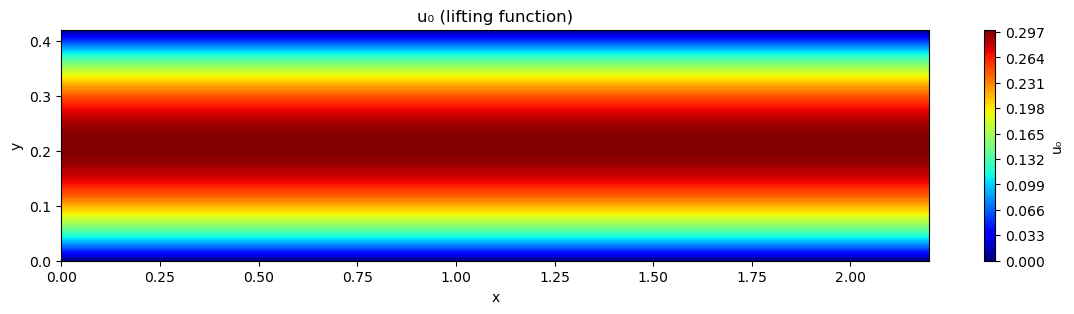

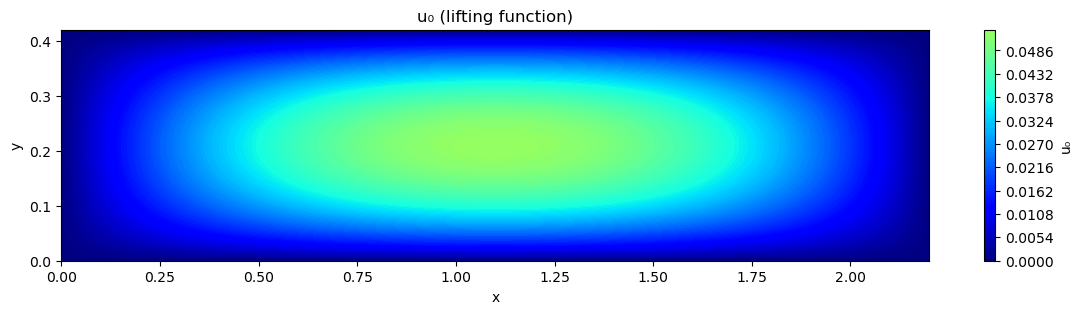

In [32]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    device=device,
    figsize=(14, 3),
    titles=['u₀ (lifting function)'],
    function_names=['u₀'],
    colour_map='jet',
    patches=[],
    vmin=-0,
    vmax=0.3,
    N=200,
)


with torch.no_grad():
    utils.plot_function_on_2d_cube([g_1], plot_ctx)

plot_ctx.vmin=0.0
plot_ctx.vmax = 0.1 
utils.plot_function_on_2d_cube([vel_0], plot_ctx)
    

In [33]:
def f_0(x: torch.Tensor) -> torch.Tensor:
    g = vel_0(x)
    return torch.column_stack([g, g, torch.ones_like(x[:, 0:1])])

def f_1(x: torch.Tensor) -> torch.Tensor:
    zeros = torch.zeros_like(x[:, 0:1])
    model_vals = g_1(x)
    return torch.column_stack([model_vals, zeros, zeros])


model_ctx = mn.MoECtx(
    input_dim=2,
    output_dims=[2, 1],
    hidden_layers_per_output=[[32, 32, 32, 32], [16, 16, 16, 16]],
    discontinuous_per_layer=[False, False],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    constraint_functions=(f_1, f_0),
)

model_uvp = mn.MoEModel(model_ctx).to(device)
optimizer_uvp = torch.optim.Adam(model_uvp.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=200)

In [ ]:
def loss(model: nn.Module, domain: aq.AquariumDomain) -> List[torch.Tensor]:
    pde_intput = domain.interior.requires_grad_(True)
    
    pde_output = model(pde_intput)
    
    u, v, p = pde_output[:, 0:1], pde_output[:, 1:2], pde_output[:, 2:3]

    u_grad = grad(u, pde_intput, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, pde_intput, torch.ones_like(v), create_graph=True)[0]
    p_grad = grad(p, pde_intput, torch.ones_like(p), create_graph=True)[0]

    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]

    u_xx = grad(u_x, pde_intput, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, pde_intput, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, pde_intput, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, pde_intput, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]

    inner_loss_1 = torch.mean((-NU * (u_xx + u_yy) + u * u_x + v * u_y + p_x)**2)
    inner_loss_2 = torch.mean((-NU * (v_xx + v_yy) + u * v_x + v * v_y + p_y)**2)
    pde_loss = inner_loss_1 + inner_loss_2
    cont_loss = torch.mean((u_x + v_y)**2)
    
    ball_pts = domain.ball_boundary.requires_grad_(True)
    ball_vals = model(ball_pts)
    ball_loss = torch.mean(ball_vals[:, 0:2]**2)

    return [pde_loss, 5 * cont_loss, ball_loss]


In [ ]:
context = train.TrainingContext(
    model=model_uvp,
    domain=domain,
    optimizer=optimizer_uvp,
    #scheduler=scheduler,
    loss_fn=loss,
    epochs=120_000,
    monitor_lr=True,
    monitor_gradient=True
)

total_loss_values, component_loss_values, grad_norm_per_loss = train.train_switch_to_lbfgs(context, lbfgs_lr=0.1, epochs_with_lbfgs=1000)

Loss at epoch 1 is: 0.04417940974235535. Total gradient norm: 0.07113411266680035 Component 0 grad norm: 0.06808028208306106 Component 1 grad norm: 0.01949136982950277 Component 2 grad norm: 0.007681507768306668 Current learing rate: 0.0001 
Loss at epoch 100 is: 0.03997090831398964. Total gradient norm: 0.0076423145249083675 Component 0 grad norm: 0.0033764589855679907 Component 1 grad norm: 0.003909021524307586 Component 2 grad norm: 0.009645761660266443 Current learing rate: 0.0001 
Loss at epoch 200 is: 0.037786904722452164. Total gradient norm: 0.004847873016151545 Component 0 grad norm: 0.001026617679346245 Component 1 grad norm: 0.009703499952449946 Component 2 grad norm: 0.014239441618734559 Current learing rate: 0.0001 
Loss at epoch 300 is: 0.03670244663953781. Total gradient norm: 0.0031555971193902846 Component 0 grad norm: 0.0008068163451075772 Component 1 grad norm: 0.013793799789317473 Component 2 grad norm: 0.01664239182281405 Current learing rate: 0.0001 
Loss at epoch

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


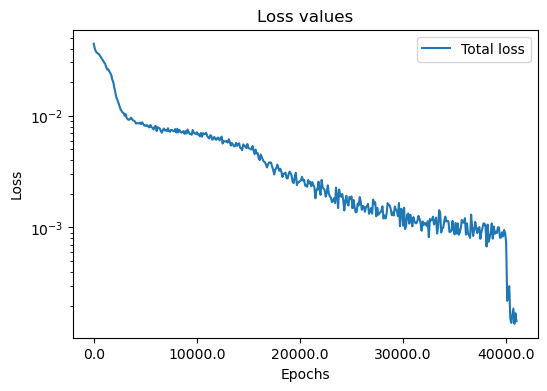

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


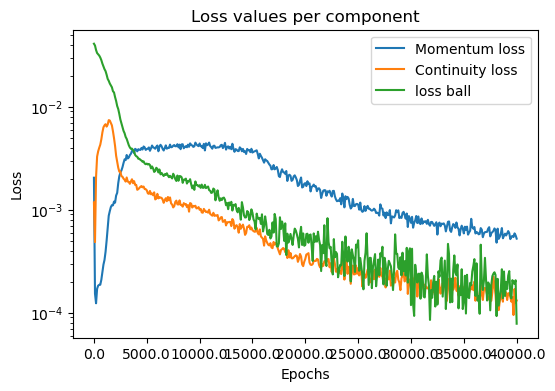

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


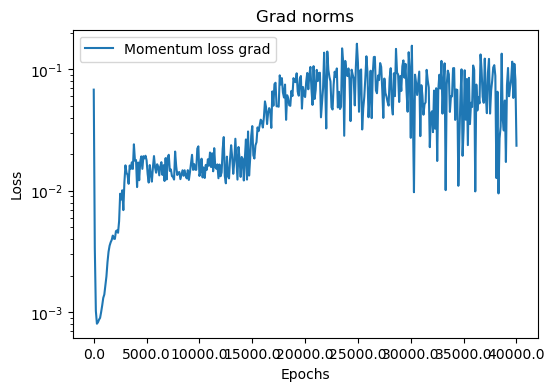

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


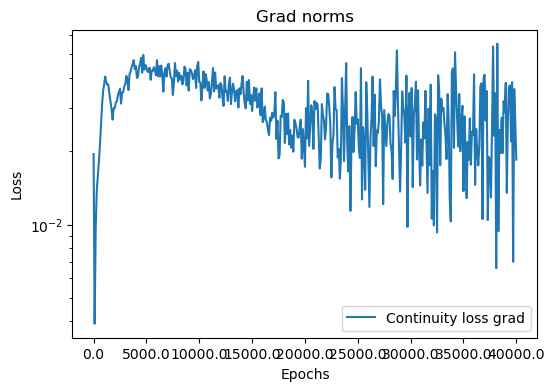

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


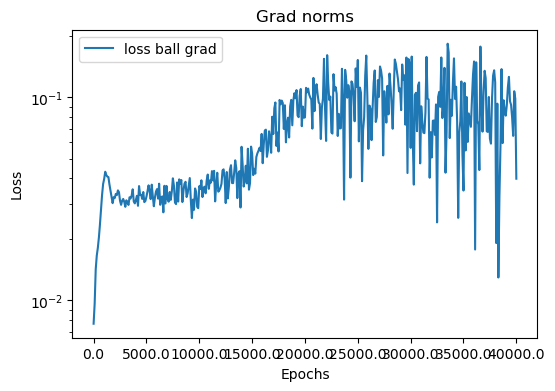

In [36]:
plot_context = utils.PlotContext(
    u_bounds=U_BOUNDS,
    l_bounds=L_BOUNDS,
    figsize=(25, 3.85),
    patches=None,
    device=device,
    vmin=0.0,
    vmax=0.4,
    N=100,
    titles=['Velocity norm'],
    function_names=['u'],
    x_label='Epochs',
    y_label='Loss',
)

plot_context.titles = ["Loss values"]
utils.plot_loss_values({'Total loss': total_loss_values}, plot_context)

plot_context.titles = ["Loss values per component"]
utils.plot_loss_values(
    {
        'Momentum loss':    component_loss_values[0],
        'Continuity loss':  component_loss_values[1],
        "loss ball":        component_loss_values[2]
    },
    plot_context,
)

plot_context.titles = ["Grad norms"]
plot_ctx.y_label = "Grad"

utils.plot_loss_values({'Momentum loss grad':    grad_norm_per_loss[0],},plot_context,)
utils.plot_loss_values({'Continuity loss grad':  grad_norm_per_loss[1],}, plot_context,)
utils.plot_loss_values({"loss ball grad":        grad_norm_per_loss[2]},plot_context,)

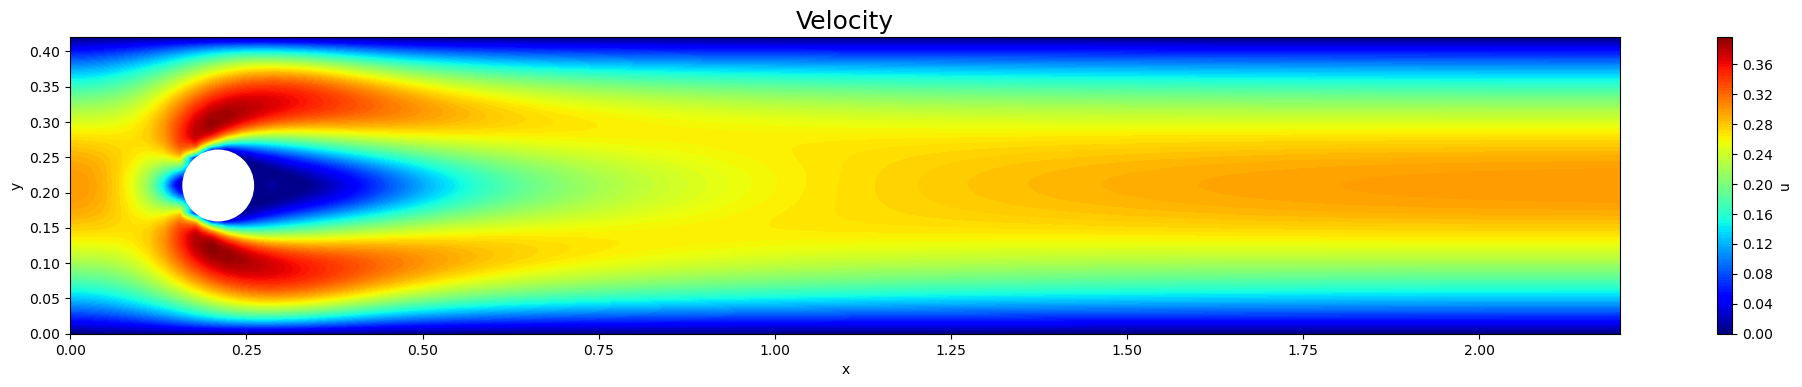

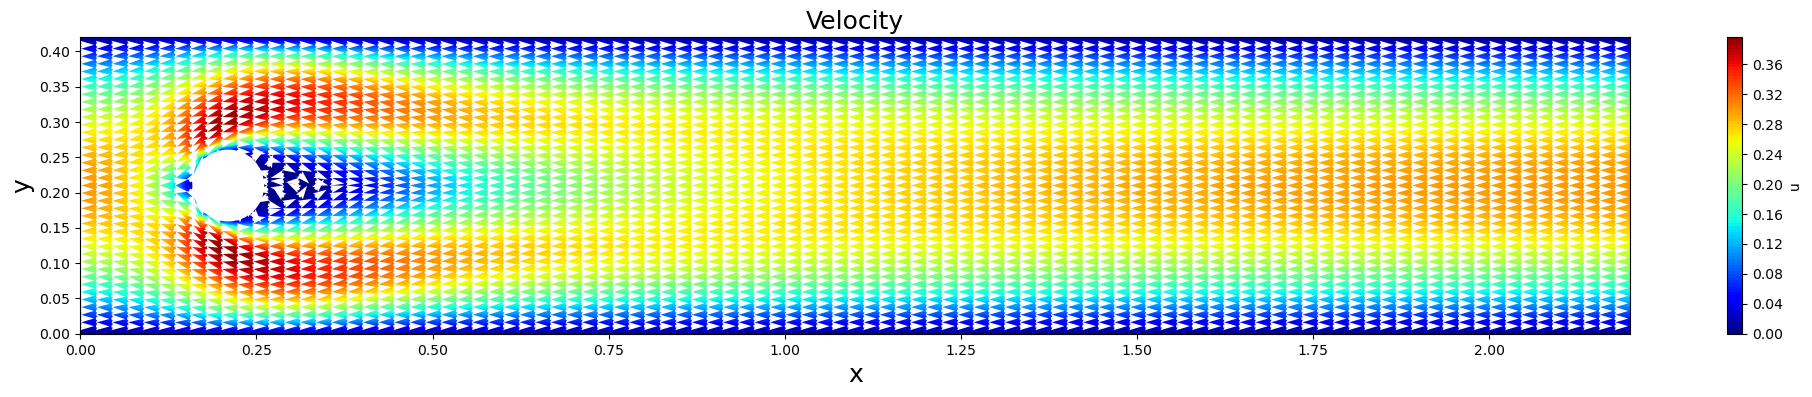

In [37]:
plot_context.patches = [plt.Circle((0.21, 0.21), 0.05, color="white", zorder=10)]
plot_context.titles = ['Velocity']
plot_context.function_names = ['u']
plot_context.x_label = 'x'
plot_context.y_label = 'y'
plot_context.fontsize = 18
plot_context.vmin = 0.0
plot_context.vmax = 0.4


def velocity(x: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        out = model_uvp(x)
    return out[:, 0:2]   # (u, v) directly from hard-encoded model


utils.plot_function_on_2d_cube([lambda x: torch.norm(velocity(x), p=2, dim=1)], plot_context)
plot_context.patches = [plt.Circle((0.21, 0.21), 0.05, color="white", zorder=10)]

utils.plot_vector_field_2d([velocity], plot_context, N=100, n_heigth=40, n_width=100)

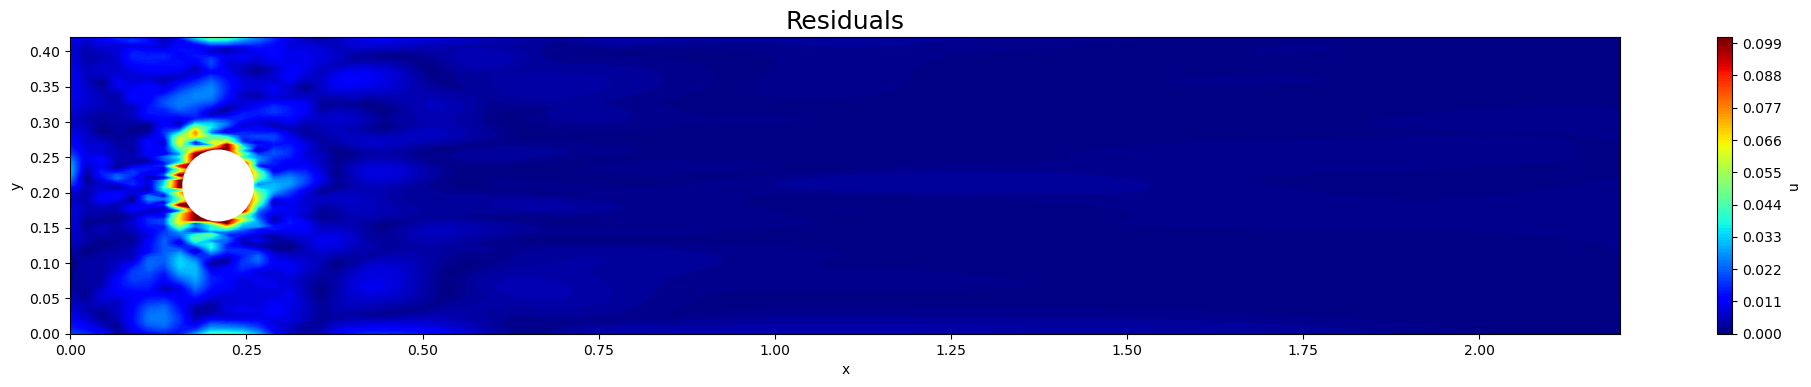

In [38]:
def residuum(x: torch.Tensor) -> torch.Tensor:
    x = x.requires_grad_(True)
    out = model_uvp(x)
    u, v, p = out[:, 0:1], out[:, 1:2], out[:, 2:3]

    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    p_grad = grad(p, x, torch.ones_like(p), create_graph=True)[0]

    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]

    u_xx = grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, x, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, x, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]

    res_1 = torch.clamp(torch.abs(-NU * (u_xx + u_yy) + u * u_x + v * u_y + p_x), 0, 0.1)
    res_2 = torch.clamp(torch.abs(-NU * (v_xx + v_yy) + u * v_x + v * v_y + p_y), 0, 0.1)
    return 0.5 * (res_1 + res_2)


plot_context.vmin = 0
plot_context.vmax = 0.1
plot_context.patches = [plt.Circle((0.21, 0.21), 0.05, color="white", zorder=10)]
plot_context.titles = ['Residuals']

utils.plot_function_on_2d_cube([residuum], plot_context)

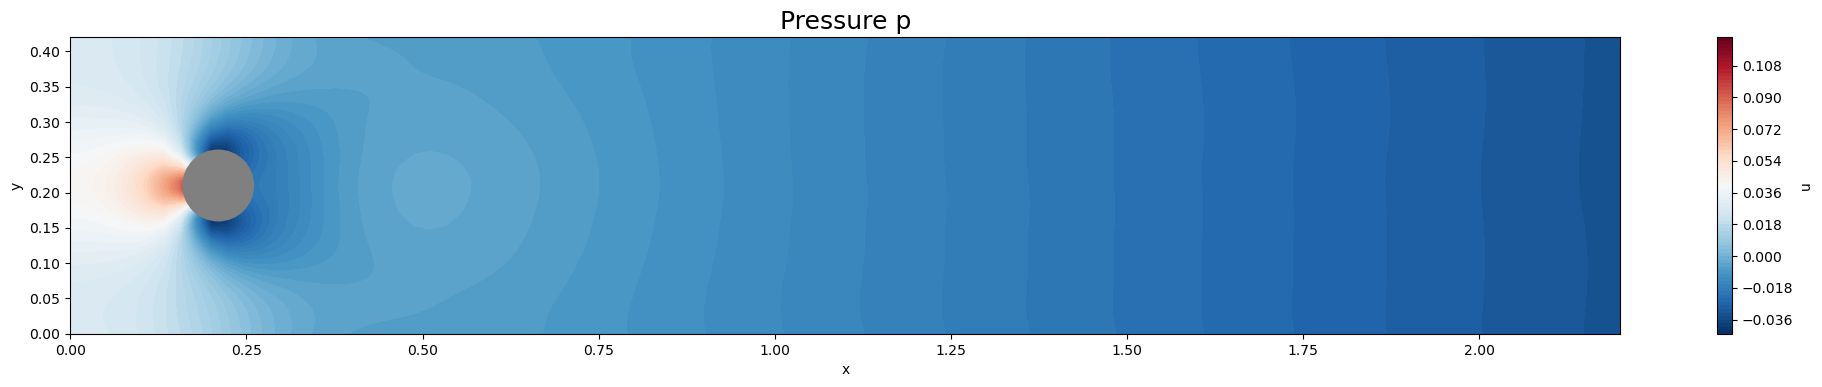

In [39]:
plot_context.vmin = None
plot_context.vmax = None
plot_context.colour_map = 'RdBu_r'
plot_context.titles = ['Pressure p']
plot_context.patches = [plt.Circle((0.21, 0.21), 0.05, color="grey", zorder=10)]

with torch.no_grad():
    utils.plot_function_on_2d_cube([lambda x: model_uvp(x)[:, 2:3]], plot_context)

In [40]:
# ── Hard-BC verification (errors should be at machine precision) ──────────────
N_test = 500
L = domain_ctx.u_bounds[0]

y_vals = torch.linspace(0, H, N_test, device=device)
x_vals = torch.linspace(0, L, N_test, device=device)

with torch.no_grad():
    # inflow (x=0)
    pts_in  = torch.stack([torch.zeros(N_test, device=device), y_vals], dim=1)
    out_in  = model_uvp(pts_in)
    u_in, v_in = out_in[:, 0], out_in[:, 1]
    u_target   = 4 * U_MAX * y_vals * (H - y_vals) / H**2

    # bottom wall (y=0)
    pts_bot = torch.stack([x_vals, torch.zeros(N_test, device=device)], dim=1)
    out_bot = model_uvp(pts_bot)

    # top wall (y=H)
    pts_top = torch.stack([x_vals, torch.full((N_test,), H, device=device)], dim=1)
    out_top = model_uvp(pts_top)

print(f"Max |u - U_in|  at inflow  (x=0) : {(u_in - u_target).abs().max().item():.2e}")
print(f"Max |v|         at inflow  (x=0) : {v_in.abs().max().item():.2e}")
print(f"Max |u|         at bottom  (y=0) : {out_bot[:, 0].abs().max().item():.2e}")
print(f"Max |v|         at bottom  (y=0) : {out_bot[:, 1].abs().max().item():.2e}")
print(f"Max |u|         at top     (y=H) : {out_top[:, 0].abs().max().item():.2e}")
print(f"Max |v|         at top     (y=H) : {out_top[:, 1].abs().max().item():.2e}")

Max |u - U_in|  at inflow  (x=0) : 0.00e+00
Max |v|         at inflow  (x=0) : 0.00e+00
Max |u|         at bottom  (y=0) : 0.00e+00
Max |v|         at bottom  (y=0) : 0.00e+00
Max |u|         at top     (y=H) : 0.00e+00
Max |v|         at top     (y=H) : 0.00e+00
